# 0 Infrastructure

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pythonjsonlogger.defaults import time_default
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cpu")

torch.manual_seed(0)
# torch.backends.cuda.matmul.allow_tf32 = True
# torch.backends.cudnn.allow_tf32 = True
# torch.set_float32_matmul_precision('high')

def make_projection(D, d, device=device):
    A = torch.randn(D, d, device="cpu")
    Q, _ = torch.linalg.qr(A)
    Q = Q.to(device)
    return Q

# A 2d sample of n_points points that forms a swissroll
def sample_underlying_2d(n_points):
    theta = np.linspace(0, 4 * np.pi, n_points)
    r = theta / (4 * np.pi) * 2.0

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    pts = np.stack([x, y], axis=1)

    pts += 0.02 * np.random.randn(*pts.shape)
    pts = torch.from_numpy(pts).float()
    return pts

C:\Users\57517\Desktop\Diffusion-ToyModel\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1 Coding for the model for training

## 1.1 The model itself

In [4]:
class MLP5(nn.Module):
    def __init__(self, x_dim, hidden_dim, out_dim, t_dim=None):
        """
        x_dim: D  (x is [B, D])
        t_dim: D  (t is [B, D]) by default
        """
        super().__init__()
        self.x_dim = x_dim
        self.t_dim = x_dim if t_dim is None else t_dim

        in_dim = self.x_dim + self.t_dim

        layers = []
        dims = [in_dim] + [hidden_dim] * 5 + [out_dim]
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.ReLU(inplace=True))
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        """
        x: [B, D]
        t: [B, D]  (per-dim time)
           (also allows [B] or [B,1], which will be broadcast to [B, t_dim])
        """
        if t.dim() == 1:
            t = t.unsqueeze(-1)  # [B, 1]

        if t.dim() == 2 and t.shape[1] == 1 and self.t_dim != 1:
            # broadcast scalar time to per-dim time if user passes [B,1]
            t = t.expand(-1, self.t_dim)  # [B, t_dim]

        assert x.dim() == 2 and x.shape[1] == self.x_dim, f"x should be [B, {self.x_dim}]"
        assert t.dim() == 2 and t.shape[1] == self.t_dim, f"t should be [B, {self.t_dim}]"

        t = t.to(dtype=x.dtype, device=x.device)
        inp = torch.cat([x, t], dim=-1)  # [B, D + t_dim]
        return self.net(inp)

In [5]:
def train_toy(
    D=16,
    d=2,
    target_type="data",
    n_samples=20000,
    batch_size=1024,
    epochs=500,
    lr=1e-3,
):
    P = make_projection(D, d)  # [D, 2]
    x_hat = sample_underlying_2d(n_samples).to(device)  # [N, 2]
    x = x_hat @ P.t()  # This projects (places) the 2D data into D-dim data on a hyperplane. It still chooses an orthogonal basis.
    
    sigma = x.std() / 3.0
    print(f"Data std: {x.std().item():.4f}")
    print(f"Using sigma: {sigma.item():.4f}")
    print(f"Data shape: {x.shape}")

    dataset = TensorDataset(x)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    model = MLP5(x_dim=D, hidden_dim=256, out_dim=D, t_dim=D).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in tqdm(range(epochs), desc=f"Training D={D}, target={target_type}"):
        for step, (x_batch,) in enumerate(loader):
            x_1 = x_batch.to(device)  # [B, D]

            B = x_1.size(0)
            x_1 = x_1 / sigma

            #  t ~ Uniform(0,1), asynchronous time for each dim
            t = torch.rand((B, D), device=device)
            
            x_0 = torch.randn_like(x_1)
            x_t = t * x_1 + (1 - t) * x_0
            # [B, 2] * [B, 2] + [B, 2] * [B, 2]
            
            model_pred = model(x_t, t)

            if target_type == "data":
                dnorm = 1.0
                v_target = (x_1 - x_t) / dnorm
                v_pred = (model_pred - x_t) / dnorm
                loss = ((v_target - v_pred) ** 2).mean()

            elif target_type == "v":
                v_target = x_1 - x_0
                loss = ((v_target - model_pred) ** 2).mean()

            opt.zero_grad()
            loss.backward()
            opt.step()
        
        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"[D={D}] Epoch {epoch + 1}/{epochs} | {target_type}-prediction loss: {loss.item():.4f}")

    return model, P, x_hat, x, sigma

## 1.2 Sampling algorithm

In [6]:
def compute_velocity(pred, x_t, t, target_type, eps=1e-4):
    """
    from data to velocity

    :param pred: model prediction (N, D)
    :param x_t: current noisy data (N, D)
    :param t: noise level (N, D)
    :param target_type: "data" or "v"
    :param eps: a safe epsilon for eliminating the possibiity of division by 0
    :return: velocity (N, D)
    """
    if target_type == "data":
        # if the model predicts x_1, the velocity is given by
        # v = (X_1 - X_t) / (1 - t)
        dist = torch.clamp(1.0-t, min = eps)
        vp = (pred - x_t) / dist
    elif target_type == "v":
        # if the model predicts v, just use v as velocity
        vp = pred
    else:
        raise ValueError(f"Unknown target_type: {target_type}")

    return vp

In [7]:
def show_point(x, P, x_true, target_type, D, cur_step=None):
    """
    visualization of the data (projected to 2d) and comparison to the real data
    """
    pred_2d = x @ P
    pred_2d_np = pred_2d.cpu().numpy()

    plt.figure(figsize=(8, 8))

    if x_true is not None:
        x_hat_np = x_true.cpu().numpy()
        plt.scatter(x_hat_np[:, 0], x_hat_np[:, 1],
                   s=10, alpha=0.4, c='blue', label="Real Data")

    plt.scatter(pred_2d_np[:, 0], pred_2d_np[:, 1],
               s=10, alpha=0.6, c='orange', label=f"Generated")

    plt.legend(fontsize=12)
    plt.title(f"Real vs Generated (D={D}, target={target_type})", fontsize=14)
    plt.xlabel('Dimension 1', fontsize=12)
    plt.ylabel('Dimension 2', fontsize=12)
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_filename = (f"illustration/real_vs_gen_target_{target_type}_D_{D}_step_{cur_step}.png"
                    if cur_step is not None
                    else f"illustration/real_vs_gen_{target_type}_D{D}.png")
    plt.savefig(save_filename, dpi=200)
    plt.show()


def visualize_2d(model, P, t_schedule = None, target_type="data",
                       x_true=None, n_points=2000, steps=None, sigma=1.0):
    """
    Use asynchronous noise schedule to sample the data, and visualize them

    :param target_type: "data" or "v"
    :param steps: number of steps to denoise
    :param t_schedule: noise schedule
    NOTE: t_schedule and steps are not ALL None.
    - If t_schedule is NOT None and steps is NOT None, the real schedule is a linear interpolation of the t_schedule with "steps" steps
    - If t_schedule is NOT None and steps IS None, the real denoising schedule is t_schedule.
    - If t_schedule IS None and steps is NOT None, the real denoising schedule is a uniform homogenous schedule with "steps" steps.
    - If both of them are None, it will throw an exception.
    """
    model.eval()
    P = P.to(device)
    D, d = P.shape # data dimension
    if t_schedule is None:
        if steps is None:
            raise ValueError("one of t_schedule and steps must not be None!")
        else:
            t_schedule = torch.tensor([[i/steps for i in range(steps+1)] for _ in range(D)])
    M = t_schedule.shape[1] - 1 # schedule step

    x = torch.randn(n_points, D, device=device)
    if steps is None:
        steps = M

    print(f"Sampling with async schedule:")
    print(f"  D={D}, M={M}, steps={steps}")
    print(f"  Target type: {target_type}")
    print(f"  Generating {n_points} samples")

    for i in range(steps):
        with torch.no_grad():
            progress = i / steps

            # for steps > M, we linearly interpolate to get t_current
            idx_float = progress * M
            idx_low = int(idx_float)
            idx_high = min(idx_low + 1, M)
            weight = idx_float - idx_low

            t_current = torch.zeros(D, device=device)
            for dim in range(D):
                t_low = t_schedule[dim, idx_low]
                t_high = t_schedule[dim, idx_high]
                t_current[dim] = t_low * (1 - weight) + t_high * weight

            # also, linearly interpolate to get t_next
            if i < steps - 1:
                progress_next = (i + 1) / steps
                idx_float_next = progress_next * M
                idx_low_next = int(idx_float_next)
                idx_high_next = min(idx_low_next + 1, M)
                weight_next = idx_float_next - idx_low_next

                t_next = torch.zeros(D, device=device)
                for dim in range(D):
                    t_low_next = t_schedule[dim, idx_low_next]
                    t_high_next = t_schedule[dim, idx_high_next]
                    t_next[dim] = t_low_next * (1 - weight_next) + t_high_next * weight_next
            else:
                t_next = torch.ones(D, device=device)

            dt = t_next - t_current
            print(dt)

            t = t_current.unsqueeze(0).expand(n_points, D)
            dt_expanded = dt.unsqueeze(0).expand(n_points, D)

            x_t = x
            pred = model(x_t, t)

            # from target_type calculate velocity
            vp = compute_velocity(pred, x_t, t, target_type)

            x = x_t + dt_expanded * vp

    print(f"Sampling complete!")

    # then this is the real visualization
    if x_true is not None:
        show_point(x * sigma, P, x_true, target_type, D)

    return x * sigma



## 1.3 Show the initial results of the generated model

Here, we show the result for the same settings with different scales and the method.


=== Training D=4, target=data ===
Data std: 0.5775
Using sigma: 0.1925
Data shape: torch.Size([20000, 4])


Training D=4, target=data:   0%|          | 1/500 [00:00<03:10,  2.61it/s]

[D=4] Epoch 1/500 | data-prediction loss: 1.9130


Training D=4, target=data:  10%|█         | 50/500 [00:13<02:10,  3.45it/s]

[D=4] Epoch 50/500 | data-prediction loss: 0.7585


...

Training D=4, target=data:  90%|█████████ | 450/500 [02:10<00:14,  3.57it/s]

[D=4] Epoch 450/500 | data-prediction loss: 0.6991


Training D=4, target=data: 100%|██████████| 500/500 [02:28<00:00,  3.37it/s]

[D=4] Epoch 500/500 | data-prediction loss: 0.6920
Sampling with async schedule:
  D=4, M=100, steps=100
  Target type: data
  Generating 20000 samples
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])


tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 

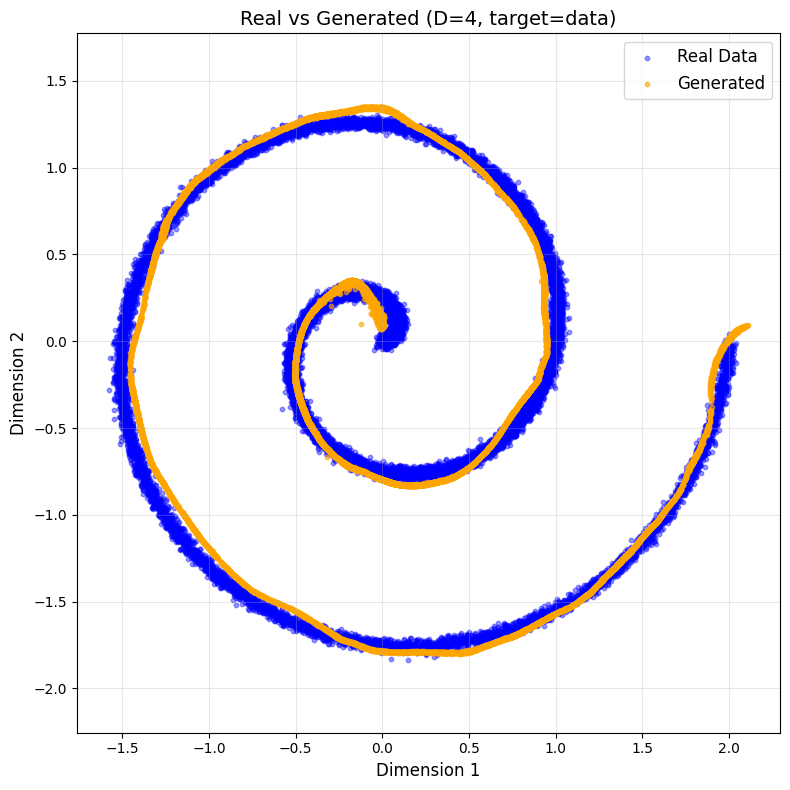


=== Training D=4, target=v ===
Data std: 0.5774
Using sigma: 0.1925
Data shape: torch.Size([20000, 4])


Training D=4, target=v:   0%|          | 1/500 [00:00<02:54,  2.86it/s]

[D=4] Epoch 1/500 | v-prediction loss: 3.8809


Training D=4, target=v:  10%|█         | 50/500 [00:18<04:08,  1.81it/s]

[D=4] Epoch 50/500 | v-prediction loss: 1.7921


...

Training D=4, target=v:  90%|█████████ | 450/500 [02:32<00:17,  2.88it/s]

[D=4] Epoch 450/500 | v-prediction loss: 1.4379


Training D=4, target=v: 100%|██████████| 500/500 [02:49<00:00,  2.96it/s]

[D=4] Epoch 500/500 | v-prediction loss: 1.6494
Sampling with async schedule:
  D=4, M=100, steps=100
  Target type: v
  Generating 20000 samples
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])


tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 

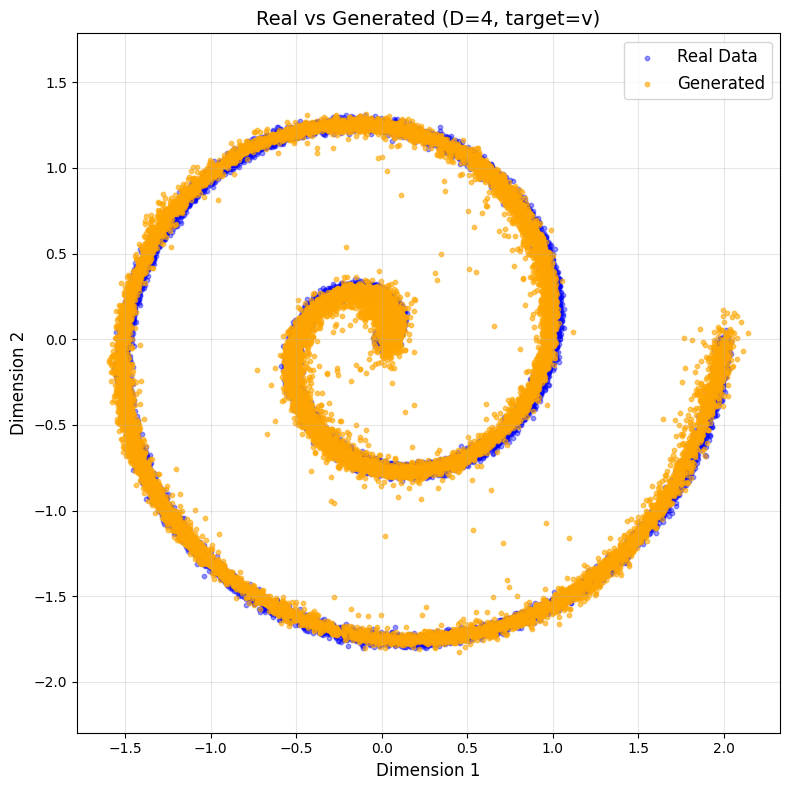


=== Training D=16, target=data ===
Data std: 0.2888
Using sigma: 0.0963
Data shape: torch.Size([20000, 16])


Training D=16, target=data:   0%|          | 1/500 [00:00<03:41,  2.26it/s]

[D=16] Epoch 1/500 | data-prediction loss: 1.1579


Training D=16, target=data:  10%|█         | 50/500 [00:19<02:45,  2.72it/s]

[D=16] Epoch 50/500 | data-prediction loss: 0.0888


...

Training D=16, target=data:  90%|█████████ | 450/500 [02:40<00:16,  3.07it/s]

[D=16] Epoch 450/500 | data-prediction loss: 0.0325


Training D=16, target=data: 100%|██████████| 500/500 [02:58<00:00,  2.80it/s]

[D=16] Epoch 500/500 | data-prediction loss: 0.0302
Sampling with async schedule:
  D=16, M=100, steps=100
  Target type: data
  Generating 20000 samples
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])


tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.

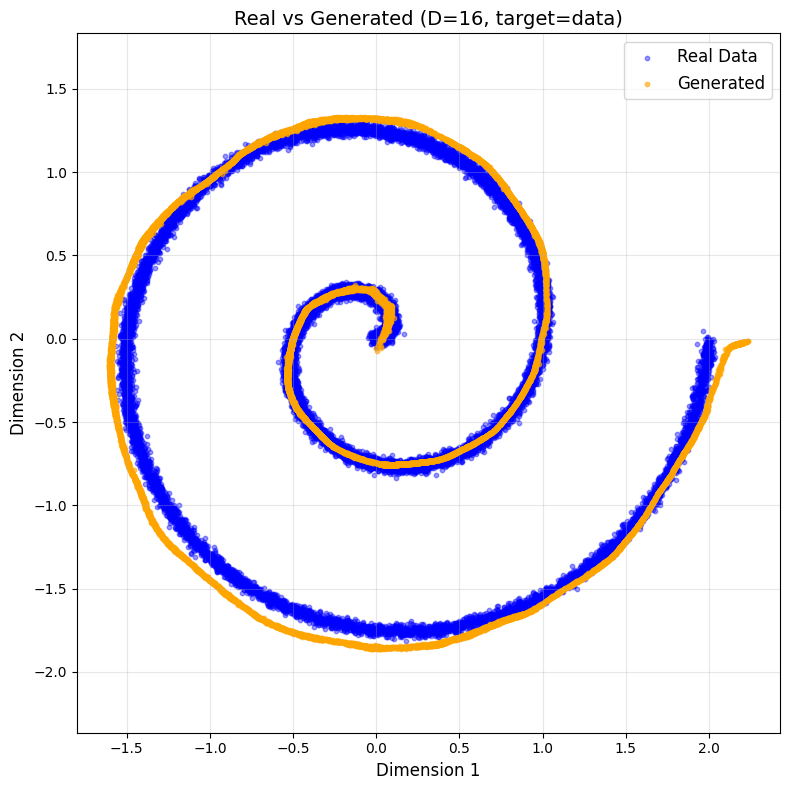


=== Training D=16, target=v ===
Data std: 0.2887
Using sigma: 0.0962
Data shape: torch.Size([20000, 16])


Training D=16, target=v:   0%|          | 1/500 [00:00<02:40,  3.10it/s]

[D=16] Epoch 1/500 | v-prediction loss: 2.4913


Training D=16, target=v:  10%|█         | 50/500 [00:21<02:58,  2.52it/s]

[D=16] Epoch 50/500 | v-prediction loss: 0.8131


...

Training D=16, target=v:  90%|█████████ | 450/500 [02:36<00:18,  2.75it/s]

[D=16] Epoch 450/500 | v-prediction loss: 0.3129


Training D=16, target=v: 100%|██████████| 500/500 [02:54<00:00,  2.87it/s]

[D=16] Epoch 500/500 | v-prediction loss: 0.3004
Sampling with async schedule:
  D=16, M=100, steps=100
  Target type: v
  Generating 20000 samples
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])


tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.

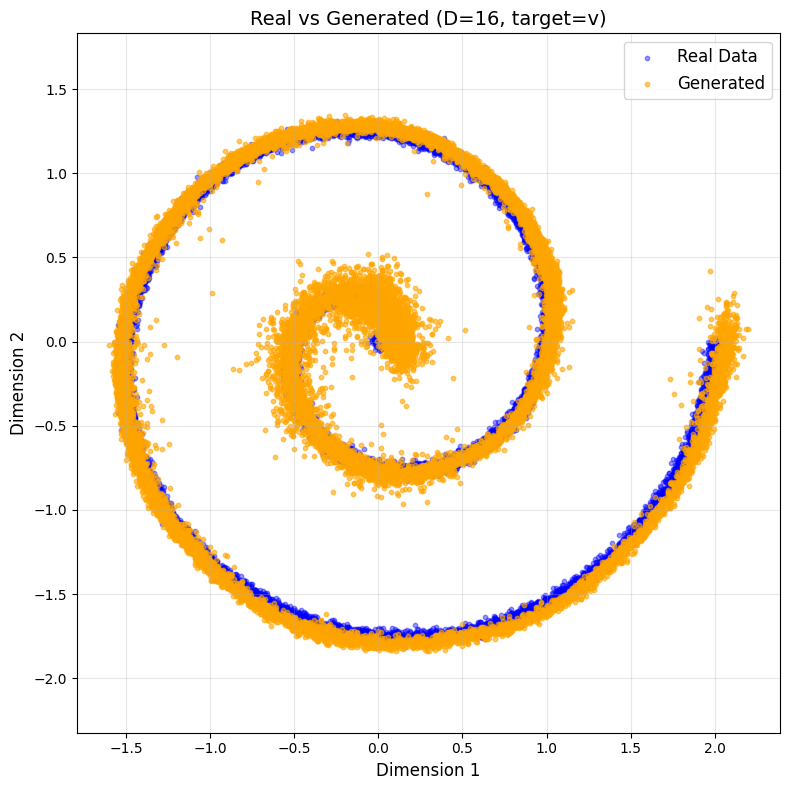


=== Training D=512, target=data ===
Data std: 0.0510
Using sigma: 0.0170
Data shape: torch.Size([20000, 512])


Training D=512, target=data:   0%|          | 1/500 [00:00<06:19,  1.31it/s]

[D=512] Epoch 1/500 | data-prediction loss: 0.8001


Training D=512, target=data:  10%|█         | 50/500 [00:41<06:28,  1.16it/s]

[D=512] Epoch 50/500 | data-prediction loss: 0.0216


...

Training D=512, target=data:  90%|█████████ | 450/500 [06:15<00:38,  1.28it/s]

[D=512] Epoch 450/500 | data-prediction loss: 0.0058


Training D=512, target=data: 100%|██████████| 500/500 [06:56<00:00,  1.20it/s]

[D=512] Epoch 500/500 | data-prediction loss: 0.0052
Sampling with async schedule:
  D=512, M=100, steps=100
  Target type: data
  Generating 20000 samples


tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 

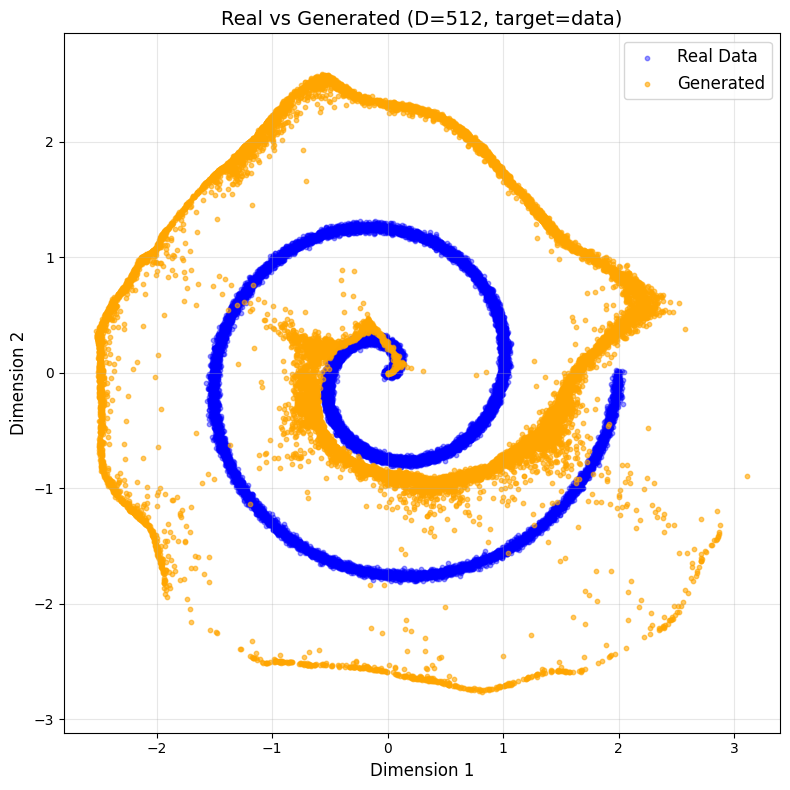


=== Training D=512, target=v ===
Data std: 0.0511
Using sigma: 0.0170
Data shape: torch.Size([20000, 512])


Training D=512, target=v:   0%|          | 1/500 [00:00<06:11,  1.34it/s]

[D=512] Epoch 1/500 | v-prediction loss: 2.0092


Training D=512, target=v:  10%|█         | 50/500 [00:42<06:49,  1.10it/s]

[D=512] Epoch 50/500 | v-prediction loss: 1.0259


...

Training D=512, target=v:  90%|█████████ | 450/500 [06:19<00:51,  1.03s/it]

[D=512] Epoch 450/500 | v-prediction loss: 0.9878


Training D=512, target=v: 100%|██████████| 500/500 [07:16<00:00,  1.14it/s]

[D=512] Epoch 500/500 | v-prediction loss: 0.9854
Sampling with async schedule:
  D=512, M=100, steps=100
  Target type: v
  Generating 20000 samples


tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 

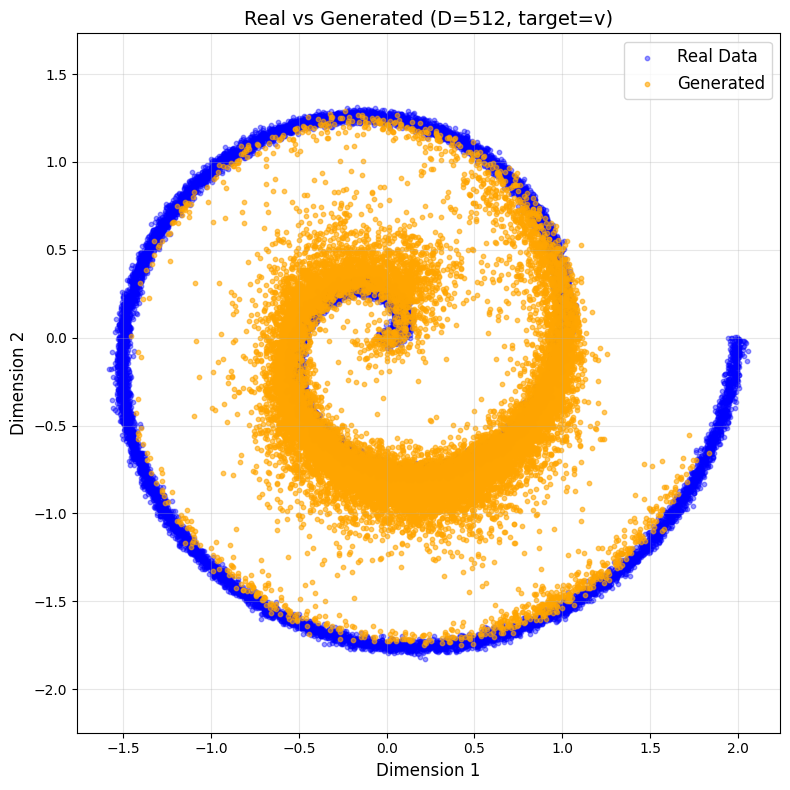

In [8]:
Ds = [4, 16, 512]
target_types = ["data", "v"]

for D in Ds:
    for tt in target_types:
        print(f"\n=== Training D={D}, target={tt} ===")
        model, P, x_hat, x, sigma = train_toy(
            D=D,
            d=2,
            target_type=tt,
            n_samples=20000,
            batch_size=1024,
            epochs=500,
            lr=1e-3,
        )
        visualize_2d(model, P, n_points=20000, target_type=tt, steps=100, x_true=x_hat, sigma=sigma)

# 2 Calculating the loss.

Now we calculate the loss and look at the gradient. We look at the loss value for different $t$ (it is a scalar now).



# 2.1 target predicting data.

In [9]:
model, P, x_hat, x, sigma = train_toy(
    D=4,
    d=2,
    target_type="data",
    n_samples=20000,
    batch_size=1024,
    epochs=500,
    lr=1e-3,
)

Data std: 0.5772
Using sigma: 0.1924
Data shape: torch.Size([20000, 4])


Training D=4, target=data:   0%|          | 1/500 [00:00<03:38,  2.28it/s]

[D=4] Epoch 1/500 | data-prediction loss: 2.1700


Training D=4, target=data:  10%|█         | 50/500 [00:23<02:39,  2.82it/s]

[D=4] Epoch 50/500 | data-prediction loss: 0.7505


...

[D=4] Epoch 400/500 | data-prediction loss: 0.5968


Training D=4, target=data:  90%|█████████ | 450/500 [02:45<00:20,  2.50it/s]

[D=4] Epoch 450/500 | data-prediction loss: 0.5478


Training D=4, target=data: 100%|██████████| 500/500 [03:02<00:00,  2.73it/s]

[D=4] Epoch 500/500 | data-prediction loss: 0.6985


In [10]:
N = 50
losses = []
grads = []
for t_scalar in [i/N for i in range(N+1)]:
    sigma = x.std() / 3.0
    t_torch = torch.tensor(t_scalar, requires_grad=True)
    t = t_torch.expand_as(x)
    B = x.size(0)
    x_1 = x / sigma

    x_0 = torch.randn_like(x_1)
    x_t = t * x_1 + (1 - t) * x_0
    # [B, 2] * [B, 2] + [B, 2] * [B, 2]

    model_pred = model(x_t, t)
    v_target = x_1 - x_0
    loss = ((v_target - model_pred) ** 2).mean()
    loss2 = torch.clone(loss)
    losses.append(loss2.detach().numpy())
    loss.backward()
    grads.append(t_torch.grad.detach().numpy())

We look at the loss and grad value for different $t$ (it is a scalar now)

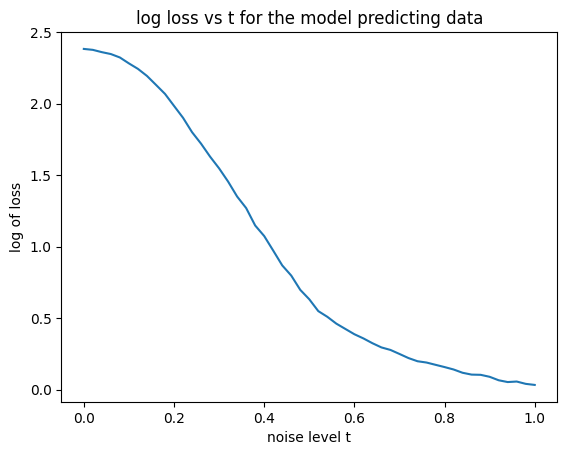

In [11]:
from matplotlib import pyplot as plt
import math
plt.title("log loss vs t for the model predicting data")
plt.xlabel("noise level t")
plt.ylabel("log of loss")
plt.plot([i/N for i in range(N+1)], [np.log(loss) for loss in losses])
plt.savefig("illustration/losses_vs_t_data.png")

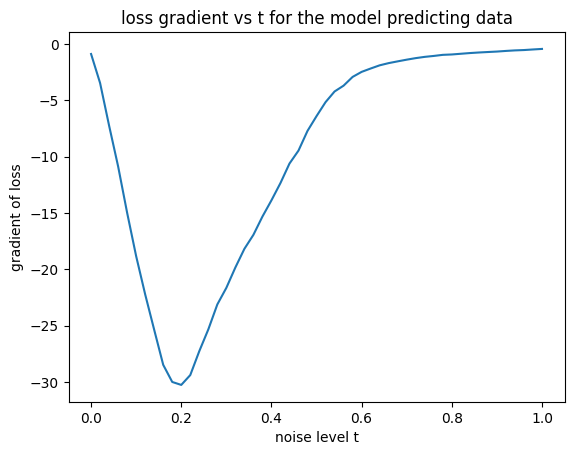

In [12]:
from matplotlib import pyplot as plt
import math
plt.title("loss gradient vs t for the model predicting data")
plt.xlabel("noise level t")
plt.ylabel("gradient of loss")
plt.plot([i/N for i in range(N+1)], grads)
plt.savefig("illustration/grads_vs_t_data.png")

# 2.2 Target predicting v

In [13]:
model, P, x_hat, x, sigma = train_toy(
    D=4,
    d=2,
    target_type="v",
    n_samples=20000,
    batch_size=1024,
    epochs=500,
    lr=1e-3,
)

Data std: 0.5767
Using sigma: 0.1922
Data shape: torch.Size([20000, 4])


Training D=4, target=v:   0%|          | 1/500 [00:00<03:52,  2.14it/s]

[D=4] Epoch 1/500 | v-prediction loss: 3.8391


Training D=4, target=v:  10%|█         | 50/500 [00:27<04:13,  1.77it/s]

[D=4] Epoch 50/500 | v-prediction loss: 1.8678


...

[D=4] Epoch 400/500 | v-prediction loss: 1.3969


Training D=4, target=v:  90%|█████████ | 450/500 [02:55<00:17,  2.82it/s]

[D=4] Epoch 450/500 | v-prediction loss: 1.6614


Training D=4, target=v: 100%|██████████| 500/500 [03:12<00:00,  2.60it/s]

[D=4] Epoch 500/500 | v-prediction loss: 1.4557


In [14]:
N = 50
losses = []
grads = []
for t_scalar in [i/N for i in range(N+1)]:
    sigma = x.std() / 3.0
    t_torch = torch.tensor(t_scalar, requires_grad=True)
    t = t_torch.expand_as(x)
    B = x.size(0)
    x_1 = x / sigma

    x_0 = torch.randn_like(x_1)
    x_t = t * x_1 + (1 - t) * x_0
    # [B, 2] * [B, 2] + [B, 2] * [B, 2]

    model_pred = model(x_t, t)
    v_target = x_1 - x_0
    loss = ((v_target - model_pred) ** 2).mean()
    loss2 = torch.clone(loss)
    losses.append(loss2.detach().numpy())
    loss.backward()
    grads.append(t_torch.grad.detach().numpy())

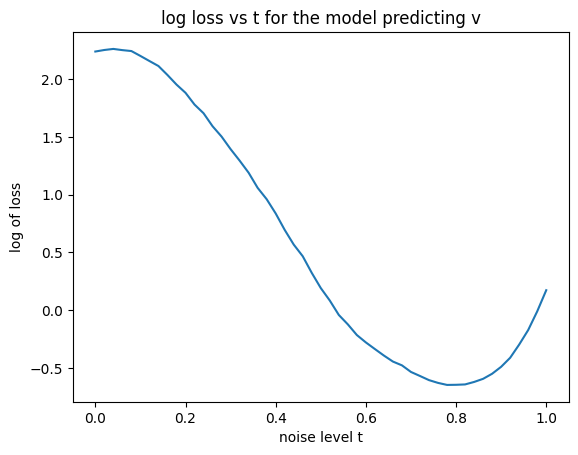

In [15]:
from matplotlib import pyplot as plt
import math
plt.title("log loss vs t for the model predicting v")
plt.xlabel("noise level t")
plt.ylabel("log of loss")
plt.plot([i/N for i in range(N+1)], [np.log(loss) for loss in losses])
plt.savefig("illustration/losses_vs_t_v.png")

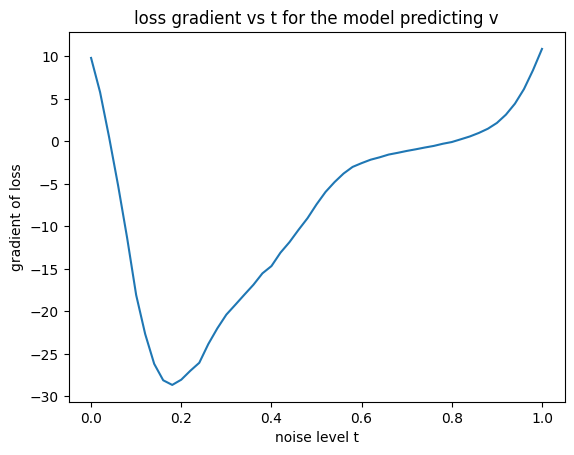

In [16]:
from matplotlib import pyplot as plt
import math
plt.title("loss gradient vs t for the model predicting v")
plt.xlabel("noise level t")
plt.ylabel("gradient of loss")
plt.plot([i/N for i in range(N+1)], grads)
plt.savefig("illustration/grads_vs_t_data.png")

# 3 Learning and optimizing the schedule

Now we are going to minimize the target function if we are predicting $h(X_t, t) = \mathbb E[X_1|X_t, t]$, we should minimize

$$\int_{t} \sum_{j}\frac{t_j\mathrm dt_j}{(1-t_j)^3}\mathbb E[(h(X_t,t)-\mathbb E[X_1|X_t,t])^2].$$

We use a discretizaion to calculate the this interval. That is, if out noise schedure is $t_{j,T}$, we calculate
$$L(t)=\sum_T \sum_{j}\frac{(t_{j,T}-t_{j,T-1})\cdot t_{j,T}}{(1-t_{j,T})^3}\mathbb E[(h(X_t,t)-\mathbb E[X_1|X_t,t])]^2.$$

In practice, when we have $N$ samples, we do the following:
$$L(t)=\sum_T \sum_{j}\frac{(t_{j,T}-t_{j,T-1})\cdot t_{j,T}}{\color{red}(1-t_{j,T})^3}\cdot \frac{1}{N}\sum_{s=1}^N (h(X_t^{(s)},t)-X_1^{(s)})^2.$$

Similarly, if we are predicting the speed, i.e., $h(X_t,t)=\mathbb E[X_1-X_0|X_t, t]$, the weight for the $L(T)$ should be (the weight is different)

$$L(t)=\sum_T \sum_{j}\frac{(t_{j,T}-t_{j,T-1})\cdot t_{j,T}}{\color{red}{1-t_{j,T}}}\cdot \frac{1}{N}\sum_{s=1}^N (h(X_t^{(s)},t)-(X_1^{(s)}-X_0^{(s)}))^2.$$


The per-dim noise schedule is $t\in\mathbb R^{(M+1)\times d}$, where $d$ is the number dimension of the data and $M$ is the step. The noise schedule $t$ initially are given by linear: $t_{i}$ is a all $i/M$ vector for $i=0,1,\dots,N$. We want the following holds during the training process:

- For any $0\le i\le M$, the total sum of $t_i$ is $i\cdot d/M$. Specifically, $t_0$ is an all-zero vector and $t_1$ is all-one vector.

We do **NOT** have a good idea for splitting the intervals. We just use the uniform splitting here.

- For any $1\le i\le M-1$ and $1\le j\le d$, $t_{i-1,j}\le t_{i,j}\le t_{i+1,j}$.

Our algorithm is as follows:

- Calculate $L(T)=\sum_i \sum_{j}\frac{(t_{i,j}-t_{i-1,j})\cdot t_{i,j}}{(1-t_{i,j})^3}\cdot\frac{1}{N}\sum_{s=1}^N(h_j(X_t^{(s)},t)-{X_t^{(s)}}_j)^2.$ Here, $X^{(s)}$ denotes the $s$th sample. Since we are NOT using the same noise level per dimension, for $j$th dimension, it is given as $X_j = (1-t_{i,j}) \mathcal N(0,1) + t_{i,j} {X_1}_j$ be the noisy sample with noise level (per dimension) $t_{i,j}$. You can choose the random $\mathcal N(0,1)$ to be fixed or not fixed during the training process.
- Looping the followings for $n$ epochs:
- - For each odd number $i$ (it can be done in batch), the gradient of $g_i = \partial L/\partial t_{i}$. $g_i'$ is the vector projecting $g_i$ to the hyperplane $t_{i,1}+\dots+t_{i,d}=0$. Then, we update this noise level by a gradient descent: $t_i' = t_i -\lambda \cdot g_i$, then clamp every coordinate monotonically: $t_{i-1,j}\le t_{i,j}\le t_{i+1,j}$. Here, $\lambda$ is the learning rate.
- - For each even number $i$, do the same.

Then you can get an updated $t$.

## 3.1 Observe the visualization when targeting data

In [26]:
def compute_weight(t, dt, target_type, eps=1e-3):
    clamped_1mt = torch.clamp(1. - t, min=eps)
    if target_type == "data":
        return dt * t / (clamped_1mt ** 3)
    elif target_type == "v":
        return dt * t / clamped_1mt
    else:
        raise ValueError(f"Unknown target_type: {target_type}")

def weight_with_caps_and_normalize(
    t_for_weight, dt, target_type, D,
    eps=1e-3, weight_max_cap=10.0, weight_min_cap=0.1,
    normalize_per_step=True, norm_target=None
):
    """
    1) compute theoretical weight
    2) clamp to [min_cap, max_cap]  (your current choice)
    3) OPTIONAL: normalize so sum_d w[d] = norm_target (default D)
       This keeps every step "visible" but preserves relative differences across dims.
    """
    w = compute_weight(t_for_weight, dt, target_type, eps)
    w = torch.clamp(w, min=weight_min_cap, max=weight_max_cap)

    if normalize_per_step:
        if norm_target is None:
            norm_target = float(D)
        w = w * (norm_target / (w.sum() + 1e-12))
    return w

def total_loss(x_1, t, model, target_type="data", x_0=None,
                    eps=1e-3, safe_ratio=1.0, weight_max_cap = 10.0, weight_min_cap = 0.1):
    """
    Calculate the Girsanov loss

    :param target_type: "data" or "v"
    """
    N, D = x_1.shape
    M = t.shape[1] - 1

    if x_0 is None:
        x_0 = torch.randn_like(x_1)

    total = 0.0
    max_i = int(safe_ratio * M)

    for i in range(1, max_i):
        t_i = t[:, i]
        t_i_prev = t[:, i-1]

        t_expanded = t_i.unsqueeze(0).expand(N, D)
        x_t = t_expanded * x_1 + (1 - t_expanded) * x_0

        with torch.no_grad():
            pred = model(x_t, t_expanded)

        # using target_type to calculate MSE
        if target_type == "data":
            # for X_1
            mse_per_dim = ((pred - x_1) ** 2).mean(dim=0)
        elif target_type == "v":
            # for velocity.
            # In rectified flow，v = X_1 - X_0
            true_v = x_1 - x_0
            mse_per_dim = ((pred - true_v) ** 2).mean(dim=0)

        dt = t_i - t_i_prev

        # calculating the weight using target_type
        weight = compute_weight(t_i, dt, target_type, eps)
        weight = torch.clamp(weight, max = weight_max_cap, min = weight_min_cap)

        total += (mse_per_dim * weight).sum()

    return total


def project_gradient_to_hyperplane(grad):
    return grad - grad.mean()

def _project_to_box_sum(u, lo, hi, target_sum, iters=50):
    """
    Project vector u onto {x: lo<=x<=hi, sum(x)=target_sum} by finding lambda s.t.
    x = clamp(u + lambda, lo, hi) has desired sum.
    """
    # Feasibility check (optional but very helpful for debugging)
    min_sum = lo.sum()
    max_sum = hi.sum()
    if target_sum < min_sum:
        # best feasible: stick to lo
        return lo.clone()
    if target_sum > max_sum:
        # best feasible: stick to hi
        return hi.clone()

    # Bisection on lambda
    # Lower/upper bounds that are surely enough:
    # if lambda very negative -> x=lo; very positive -> x=hi
    lam_lo = (lo - u).min().item() - 1.0
    lam_hi = (hi - u).max().item() + 1.0

    for _ in range(iters):
        lam_mid = 0.5 * (lam_lo + lam_hi)
        x = torch.clamp(u + lam_mid, min=lo, max=hi)
        s = x.sum().item()
        if s < target_sum:
            lam_lo = lam_mid
        else:
            lam_hi = lam_mid
    return torch.clamp(u + 0.5 * (lam_lo + lam_hi), min=lo, max=hi)


def grad_update(x_0, x_1, t, model, target_type, parity,
                learning_rate=0.1, eps=1e-3, safe_ratio=1.0,
                weight_max_cap=10.0, weight_min_cap=0.1):
    N, D = x_1.shape
    M = t.shape[1] - 1
    t_new = t.clone()

    max_idx = int(safe_ratio * M)

    if parity == 0:
        indices = list(range(2, max_idx, 2))
    else:
        indices = list(range(1, max_idx, 2))

    if len(indices) == 0:
        return t_new

    for idx in indices:
        # optimize this column
        t_var = t_new[:, idx].clone().detach().requires_grad_(True)

        # neighbors fixed during this update
        t_prev = t_new[:, idx - 1].detach()
        t_next = t_new[:, idx + 1].detach() if (idx + 1 <= M) else None

        # ===== term at idx =====
        t_exp = t_var.unsqueeze(0).expand(N, D)
        x_t = t_exp * x_1 + (1.0 - t_exp) * x_0
        pred = model(x_t, t_exp)

        if target_type == "data":
            mse_dim = ((pred - x_1) ** 2).mean(dim=0)        # [D]
        elif target_type == "v":
            true_v = x_1 - x_0
            mse_dim = ((pred - true_v) ** 2).mean(dim=0)     # [D]
        else:
            raise ValueError(f"Unknown target_type: {target_type}")

        dt = t_var - t_prev
        w = weight_with_caps_and_normalize(
            t_for_weight=t_var, dt=dt, target_type=target_type, D=D,
            eps=eps, weight_max_cap=weight_max_cap, weight_min_cap=weight_min_cap,
            normalize_per_step=True, norm_target=float(D)
        )
        loss = (mse_dim * w).sum()

        # ===== add "next" term dependency: idx affects dt_{idx+1} =====
        if (t_next is not None) and (idx + 1 < max_idx):
            t_next_exp = t_next.unsqueeze(0).expand(N, D)
            x_t_next = t_next_exp * x_1 + (1.0 - t_next_exp) * x_0
            pred_next = model(x_t_next, t_next_exp)

            if target_type == "data":
                mse_dim_next = ((pred_next - x_1) ** 2).mean(dim=0)   # [D]
            elif target_type == "v":
                true_v = x_1 - x_0
                mse_dim_next = ((pred_next - true_v) ** 2).mean(dim=0)
            else:
                raise ValueError(f"Unknown target_type: {target_type}")

            dt_next = t_next - t_var  # depends on t_var
            w_next = weight_with_caps_and_normalize(
                t_for_weight=t_next, dt=dt_next, target_type=target_type, D=D,
                eps=eps, weight_max_cap=weight_max_cap, weight_min_cap=weight_min_cap,
                normalize_per_step=True, norm_target=float(D)
            )
            loss = loss + (mse_dim_next * w_next).sum()

        # gradient step
        loss.backward()
        grad = t_var.grad
        grad = grad - grad.mean()  # keep sum direction removed

        with torch.no_grad():
            u = t_var - learning_rate * grad

            lo = t_prev + 1e-4
            hi = (t_next - 1e-4) if (t_next is not None) else torch.full_like(lo, 1.0)

            target_sum = idx * D / M
            t_new[:, idx] = _project_to_box_sum(u, lo, hi, target_sum)

    return t_new


def learning(x_1, M, model, target_type="data", epoch=100,
                  learning_rate=0.1, fixed_x0=True, eps=1e-3,
                  subsample=2000, loss_freq=10, safe_ratio=1.0,
                  weight_max_cap = 10.0, weight_min_cap = 0.1,
                  t_initial = None, file_path = None):
    """
    A safe optimizing for the schedule. Can do both target_type
    It is quicker.
    :param x_1: true data
    :param M: number of steps. Notice that the output is tensor of shape (D, M+1)!
    :param target_type: "data" or "v"
    :param fixed_x0: bool, check whether x_0 is using the fixed one throughout the learning process
    :param eps: float, still to eliminate division by zero
    :param subsample: int, subsample the data
    :param loss_freq: int, how often to compute loss
    :param safe_ratio: float, to get rid of exploding of the gradient, we don't update the data when we update the last (1-safe_ratio) portion of data.
    :param t_initial: float, initial schedule
    """
    N_samples, D = x_1.shape


    if subsample is not None and subsample < N_samples:
        indices = torch.randperm(N_samples)[:subsample]
        x_1_sub = x_1[indices]
        print(f"Using {subsample}/{N_samples} samples for optimization")
    else:
        x_1_sub = x_1
        subsample = N_samples

    if t_initial is None:
        t = torch.zeros(D, M + 1, device=x_1.device)
        for i in range(M + 1):
            t[:, i] = i / M
    else:
        t = t_initial
        assert t_initial.shape[1] == M+1

    if fixed_x0:
        x_0 = torch.randn_like(x_1_sub)
    else:
        x_0 = None

    loss_history = []

    print(f"Target type: {target_type}")
    if target_type == "data":
        print(f"  Model predicts: X_1")
        print(f"  Weight formula: t / (1-t)^3")
    elif target_type == "v":
        print(f"  Model predicts: velocity v")
        print(f"  Weight formula: t / (1-t)")

    print(f"Schedule shape: {t.shape} (D={D}, M={M})")
    print(f"Safe ratio: {safe_ratio} (optimizing only first {int(safe_ratio*M)}/{M} steps)")
    print(f"Loss frequency: every {loss_freq} epochs")

    initial_loss = total_loss(x_1_sub, t, model, target_type, x_0, eps, safe_ratio)
    print(f"Initial loss: {initial_loss.item():.6f}\n")
    loss_history.append(initial_loss.item())

    for ep in tqdm(range(epoch), desc="Optimizing"):
        if not fixed_x0:
            x_0 = torch.randn_like(x_1_sub)

        parity = 1 - (ep % 2)
        t = grad_update(x_0, x_1_sub, t, model, target_type, parity,
                            learning_rate, eps, safe_ratio, weight_max_cap, weight_min_cap)

        if (ep + 1) % loss_freq == 0 or ep == epoch - 1:
            current_loss = total_loss(x_1_sub, t, model, target_type,
                                          x_0, eps, safe_ratio, weight_max_cap, weight_min_cap)
            loss_history.append(current_loss.item())

            step_type = "odd" if parity == 1 else "even"
            print(f"Epoch {ep + 1}/{epoch} ({step_type}) | Loss: {current_loss.item():.6f}")

    if subsample < N_samples:
        x_0_full = torch.randn_like(x_1) if fixed_x0 else None
        final_loss_full = total_loss(x_1, t, model, target_type,
                                         x_0_full, eps, safe_ratio, weight_max_cap, weight_min_cap)
        print(f"\nFinal loss (full {N_samples} samples): {final_loss_full.item():.6f}")

    print(f"Final loss (subsample): {loss_history[-1]:.6f}")
    print(f"Sum constraints: {[t[:, i].sum().item() for i in [0, M//2, M]]}")

    # 可视化
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    epochs_with_loss = [0] + [i * loss_freq for i in range(1, len(loss_history) - 1)] + [epoch]
    axes[0].plot(epochs_with_loss[:len(loss_history)], loss_history, 'o-')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Optimization Progress (target={target_type})')
    axes[0].grid(True)

    im = axes[1].imshow(t.cpu().numpy(), aspect='auto', cmap='viridis')
    axes[1].set_xlabel('Time step')
    axes[1].set_ylabel('Dimension')
    axes[1].set_title('Optimized Schedule')
    axes[1].axvline(x=int(safe_ratio*M), color='red', linestyle='--',
                    linewidth=2, label=f'Safe boundary')
    axes[1].legend()
    plt.colorbar(im, ax=axes[1])

    for d in range(min(5, D)):
        axes[2].plot(t[d].cpu().numpy(), 'o-', label=f'Dim {d}', alpha=0.7)
    mean_schedule = np.array([i * D / M for i in range(M + 1)]) / D
    axes[2].plot(mean_schedule, 'k--', linewidth=2, label='Mean')
    axes[2].axvline(x=int(safe_ratio*M), color='red', linestyle='--',
                    linewidth=2, alpha=0.5)
    axes[2].set_xlabel('Step')
    axes[2].set_ylabel('t value')
    axes[2].set_title('Per-dimension Schedules')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    if file_path is None:
        file_path = f'illustration/schedule_{target_type}.png'
    plt.savefig(file_path, dpi=150)
    plt.close()

    return t, loss_history



# 5. Baysenet Learning

In [18]:
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
import random

def sample_d(lst, d):
    # Sample <=d things in the list
    n = len(lst)
    if n==0: return []
    parents = []
    probability = min(d/(n+2),1/2)
    for node in lst:
        if random.random() < probability:
            parents.append(node)
    return parents[:d]

def generate_config(n, d, b_min, b_max):
    # Sample a random Bayesnet condiguration of n vertices with <=d indegree
    order = list(range(n))
    random.shuffle(order)
    coefficient = {i:{} for i in range(n)}
    parents = {i:set() for i in range(n)}
    B = [[0]*n for _ in range(n)]
    for i in range(n):
        node = order[i]
        prt = sample_d(order[:i],d)
        parents[node] = set(prt.copy())
        for p in prt:
            abs_value = (b_min+(b_max-b_min)*random.random())
            sign = (2*random.randint(0,1)-1)
            bij = abs_value * sign
            B[p][node] = coefficient[node][p] = bij
    return order, coefficient, parents, np.array(B)

In [19]:
from collections.abc import Callable
def generate_sample(N : int,
                    order : list[int],
                    coefficient : dict[dict[int:float]],
                    noises : np.ndarray | torch.Tensor,
                    functions: list[Callable]|None = None) -> torch.Tensor:
    '''
    From the sample configuration sample a set of values.
    :param N is the number of samples
    :param order is the topological order of nodes
    :param coefficient is the coefficient of combination
    :param noises: initial noises (standard deviations).
    '''
    n = len(order)
    random = torch.randn(n, N)
    noises_tensor = torch.tensor(noises)
    initial_noise = random * noises_tensor.unsqueeze(1)
    for i in order:
        coef = coefficient[i]
        for j in coef.keys():
            initial_noise[i] = initial_noise[i] + initial_noise[j]*coef[j]
            if functions is not None:
                initial_noise[i] = functions[i](initial_noise[i])
    return initial_noise.T

In [20]:
def train(samples, target_type="data", epochs=500, batch_size=1024, lr=1e-3, normalize=True):
    """
    samples: torch.Tensor or np.ndarray, shape [N, D]
    target_type: "data" or "v"
    returns: model, sigma
    """
    # 1) Now we use outer samples
    x = torch.as_tensor(samples, dtype=torch.float32)
    if x.dim() != 2:
        raise ValueError(f"samples must be 2D [N, D], got shape={tuple(x.shape)}")

    x = x.to(device)
    N, D = x.shape

    # 2) use the same logic of sigma (std/3)
    if normalize:
        sigma = x.std() / 3.0
        # in case of std=0
        sigma = torch.clamp(sigma, min=1e-8)
    else:
        sigma = torch.tensor(1.0, device=device)

    print(f"Data std: {x.std().item():.4f}")
    print(f"Using sigma: {sigma.item():.4f}")
    print(f"Data shape: {x.shape}")

    # 3) loader
    dataset = TensorDataset(x)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    # 4) model/opt: x_dim=D, out_dim=D, t_dim=D
    model = MLP5(x_dim=D, hidden_dim=256, out_dim=D, t_dim=D).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # 5) training loop: using rectified flow
    for epoch in tqdm(range(epochs), desc=f"Training D={D}, target={target_type}"):
        for step, (x_batch,) in enumerate(loader):
            x_1 = x_batch.to(device)              # [B, D]
            B = x_1.size(0)

            x_1 = x_1 / sigma                     # same shape

            # t ~ Uniform(0,1), asynchronous time for each dim
            t = torch.rand((B, D), device=device) # [B, D]

            x_0 = torch.randn_like(x_1)           # [B, D]
            x_t = t * x_1 + (1 - t) * x_0         # [B, D]

            model_pred = model(x_t, t)            # [B, D]

            if target_type == "data":
                dnorm = 1.0
                v_target = (x_1 - x_t) / dnorm
                v_pred   = (model_pred - x_t) / dnorm
                loss = ((v_target - v_pred) ** 2).mean()

            elif target_type == "v":
                v_target = x_1 - x_0
                loss = ((v_target - model_pred) ** 2).mean()

            else:
                raise ValueError(f"Unknown target_type={target_type}, must be 'data' or 'v'")

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"[D={D}] Epoch {epoch + 1}/{epochs} | {target_type}-prediction loss: {loss.item():.4f}")

    return model, sigma

In [27]:
n = 15
d = 3
b_min = 1
b_max = 2
N = 2000
# order, coefficient, parents, B = generate_config(n, d, b_min, b_max)
order = list(range(n))
coefficient = {0:{}, 1:{0:1.0}}
for i in range(2,n):
    coefficient[i] = {i-1:0.95}
noises = torch.tensor([(1 if coefficient[i] == {} else 0.3) for i in range(len(order))])
functions = [lambda x:torch.sin(x)]*n

In [28]:
samples = generate_sample(N, order, coefficient, noises, functions)

C:\Users\57517\AppData\Local\Temp\ipykernel_52032\3449856077.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  noises_tensor = torch.tensor(noises)


In [29]:
tt="data"

In [30]:
model, sigma = train(samples, target_type=tt, epochs=500, batch_size=1024, lr=1e-3, normalize=True)

Data std: 0.5617
Using sigma: 0.1872
Data shape: torch.Size([2000, 15])


Training D=15, target=data:   1%|          | 4/500 [00:00<00:16, 30.65it/s]

[D=15] Epoch 1/500 | data-prediction loss: 8.7339


Training D=15, target=data:  11%|█         | 53/500 [00:02<00:19, 23.41it/s]

[D=15] Epoch 50/500 | data-prediction loss: 1.7144


...

[D=15] Epoch 400/500 | data-prediction loss: 1.1197


Training D=15, target=data:  91%|█████████ | 456/500 [00:14<00:01, 32.33it/s]

[D=15] Epoch 450/500 | data-prediction loss: 1.1122


Training D=15, target=data: 100%|██████████| 500/500 [00:16<00:00, 30.64it/s]

[D=15] Epoch 500/500 | data-prediction loss: 1.0851


In [31]:
t, _ = learning(x_1 = samples,
         M = n,
         model = model,
         target_type = tt,
         learning_rate = 0.001,
         epoch=1000,
         fixed_x0=True,
         loss_freq = 1,
         weight_min_cap = 0.1,
         eps = 0.05,
         safe_ratio = 1,
         file_path = f"illustration/target_{tt}_15_dim_sin_x_updated_longer_mask_markov_chain.png")

Target type: data
  Model predicts: X_1
  Weight formula: t / (1-t)^3
Schedule shape: torch.Size([15, 16]) (D=15, M=15)
Safe ratio: 1 (optimizing only first 15/15 steps)
Loss frequency: every 1 epochs
Initial loss: 90.829964



Optimizing:   0%|          | 1/1000 [00:00<05:01,  3.31it/s]

Epoch 1/1000 (odd) | Loss: 90.603584


Optimizing:   0%|          | 2/1000 [00:00<04:32,  3.67it/s]

Epoch 2/1000 (even) | Loss: 90.170120


...

Epoch 998/1000 (even) | Loss: 66.871330


Optimizing: 100%|█████████▉| 999/1000 [04:44<00:00,  3.04it/s]

Epoch 999/1000 (odd) | Loss: 66.847328


Optimizing: 100%|██████████| 1000/1000 [04:44<00:00,  3.51it/s]

Epoch 1000/1000 (even) | Loss: 66.827286
Final loss (subsample): 66.827286
Sum constraints: [0.0, 7.0, 15.0]


In [32]:
coefficient

{0: {},
 1: {0: 1.0},
 2: {1: 0.95},
 3: {2: 0.95},
 4: {3: 0.95},
 5: {4: 0.95},
 6: {5: 0.95},
 7: {6: 0.95},
 8: {7: 0.95},
 9: {8: 0.95},
 10: {9: 0.95},
 11: {10: 0.95},
 12: {11: 0.95},
 13: {12: 0.95},
 14: {13: 0.95}}

In [33]:
t

tensor([[0.0000e+00, 4.8193e-01, 4.8203e-01, 4.8213e-01, 4.8223e-01, 4.8233e-01,
         6.4516e-01, 6.4526e-01, 6.4536e-01, 6.4546e-01, 6.5010e-01, 6.5580e-01,
         6.5610e-01, 9.9866e-01, 9.9876e-01, 1.0000e+00],
        [0.0000e+00, 2.7752e-01, 2.7762e-01, 2.7772e-01, 2.7978e-01, 2.7988e-01,
         2.7998e-01, 5.2705e-01, 5.2715e-01, 5.2725e-01, 5.5330e-01, 5.9951e-01,
         6.0762e-01, 6.0774e-01, 8.2378e-01, 1.0000e+00],
        [0.0000e+00, 2.3936e-01, 2.4152e-01, 2.4162e-01, 3.1919e-01, 3.1929e-01,
         3.1939e-01, 5.6673e-01, 5.6732e-01, 7.7805e-01, 7.7815e-01, 7.7825e-01,
         7.7835e-01, 8.6107e-01, 9.7591e-01, 1.0000e+00],
        [0.0000e+00, 1.0000e-04, 2.0000e-04, 3.0000e-04, 3.2537e-01, 3.2547e-01,
         3.2557e-01, 5.4500e-01, 5.4553e-01, 7.7645e-01, 7.7655e-01, 7.7794e-01,
         8.4447e-01, 8.4457e-01, 9.1832e-01, 1.0000e+00],
        [0.0000e+00, 1.0000e-04, 2.9123e-01, 2.9133e-01, 3.4733e-01, 3.4743e-01,
         3.4753e-01, 4.0096e-01, 4.4201

In [34]:
t[:,15]

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [35]:
t

tensor([[0.0000e+00, 4.8193e-01, 4.8203e-01, 4.8213e-01, 4.8223e-01, 4.8233e-01,
         6.4516e-01, 6.4526e-01, 6.4536e-01, 6.4546e-01, 6.5010e-01, 6.5580e-01,
         6.5610e-01, 9.9866e-01, 9.9876e-01, 1.0000e+00],
        [0.0000e+00, 2.7752e-01, 2.7762e-01, 2.7772e-01, 2.7978e-01, 2.7988e-01,
         2.7998e-01, 5.2705e-01, 5.2715e-01, 5.2725e-01, 5.5330e-01, 5.9951e-01,
         6.0762e-01, 6.0774e-01, 8.2378e-01, 1.0000e+00],
        [0.0000e+00, 2.3936e-01, 2.4152e-01, 2.4162e-01, 3.1919e-01, 3.1929e-01,
         3.1939e-01, 5.6673e-01, 5.6732e-01, 7.7805e-01, 7.7815e-01, 7.7825e-01,
         7.7835e-01, 8.6107e-01, 9.7591e-01, 1.0000e+00],
        [0.0000e+00, 1.0000e-04, 2.0000e-04, 3.0000e-04, 3.2537e-01, 3.2547e-01,
         3.2557e-01, 5.4500e-01, 5.4553e-01, 7.7645e-01, 7.7655e-01, 7.7794e-01,
         8.4447e-01, 8.4457e-01, 9.1832e-01, 1.0000e+00],
        [0.0000e+00, 1.0000e-04, 2.9123e-01, 2.9133e-01, 3.4733e-01, 3.4743e-01,
         3.4753e-01, 4.0096e-01, 4.4201